In [1]:
# ── Imports + estilo IEEE / tesis ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.family':      'serif',
    'font.size':        9,
    'axes.titlesize':   9.5,
    'axes.labelsize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
    'legend.fontsize':  7.5,
    'figure.dpi':       150,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linewidth':   0.5,
    'axes.linewidth':   0.8,
    'lines.linewidth':  1.2,
})
print('Imports OK \u2705')

Imports OK ✅


In [2]:
# ── Cargar datos y calcular m\u00e9tricas ────────────────────────────────────
sim_pinn = np.load('data_Town07_pinnnmpc_final.npy',     allow_pickle=True).item()
sim_ekf  = np.load('data_Town07_pinnnmpc_final_ekf.npy', allow_pickle=True).item()
traj     = np.load('traj_dataset_Town07.npy',            allow_pickle=True).item()

print(f'PINN sin EKF : {len(sim_pinn["x"])} pasos')
print(f'PINN + EKF   : {len(sim_ekf["x"])} pasos')

def compute_metrics(sim):
    cte   = np.array(sim['crosstrack_error'])
    steer = np.array(sim['steer_rad'])
    spd   = np.array(sim['speed']) * 3.6
    return {
        'rmse': float(np.sqrt(np.mean(cte**2))),
        'mae':  float(np.mean(np.abs(cte))),
        'emax': float(np.max(np.abs(cte))),
        'tvd':  float(np.sum(np.abs(np.diff(steer)))),
        'vmed': float(np.mean(spd)),
        'vmin': float(np.min(spd)),
    }

m_p = compute_metrics(sim_pinn)
m_e = compute_metrics(sim_ekf)

labels_m = [('rmse','RMSE_cte (m)'), ('mae','MAE_cte (m)'),
            ('emax','E_max (m)'),    ('tvd','TV_\u03b4 (rad)'),
            ('vmed','V_med (km/h)'), ('vmin','V_min (km/h)')]

print('\n' + '\u2550'*60)
print(f'  {"M\u00e9trica":<18} {"NMPC-PINN":>13} {"NMPC-PINN+EKF":>15}')
print('\u2500'*60)
for key, lbl in labels_m:
    print(f'  {lbl:<18} {m_p[key]:>13.4f} {m_e[key]:>15.4f}')
print('\u2550'*60)

PINN sin EKF : 494 pasos
PINN + EKF   : 2691 pasos

════════════════════════════════════════════════════════════
  Métrica                NMPC-PINN   NMPC-PINN+EKF
────────────────────────────────────────────────────────────
  RMSE_cte (m)              0.3218          0.5602
  MAE_cte (m)               0.1601          0.4211
  E_max (m)                 1.3643          1.8559
  TV_δ (rad)                4.1016         49.6211
  V_med (km/h)             38.6218         45.9128
  V_min (km/h)             -0.0075         -0.0242
════════════════════════════════════════════════════════════


Sección zoom : pasos [500 → 650]  t = [25.0 → 32.5] s
Centro real  : x = 74.5 m,  y = -33.5 m
GPS updates en ventana: 37


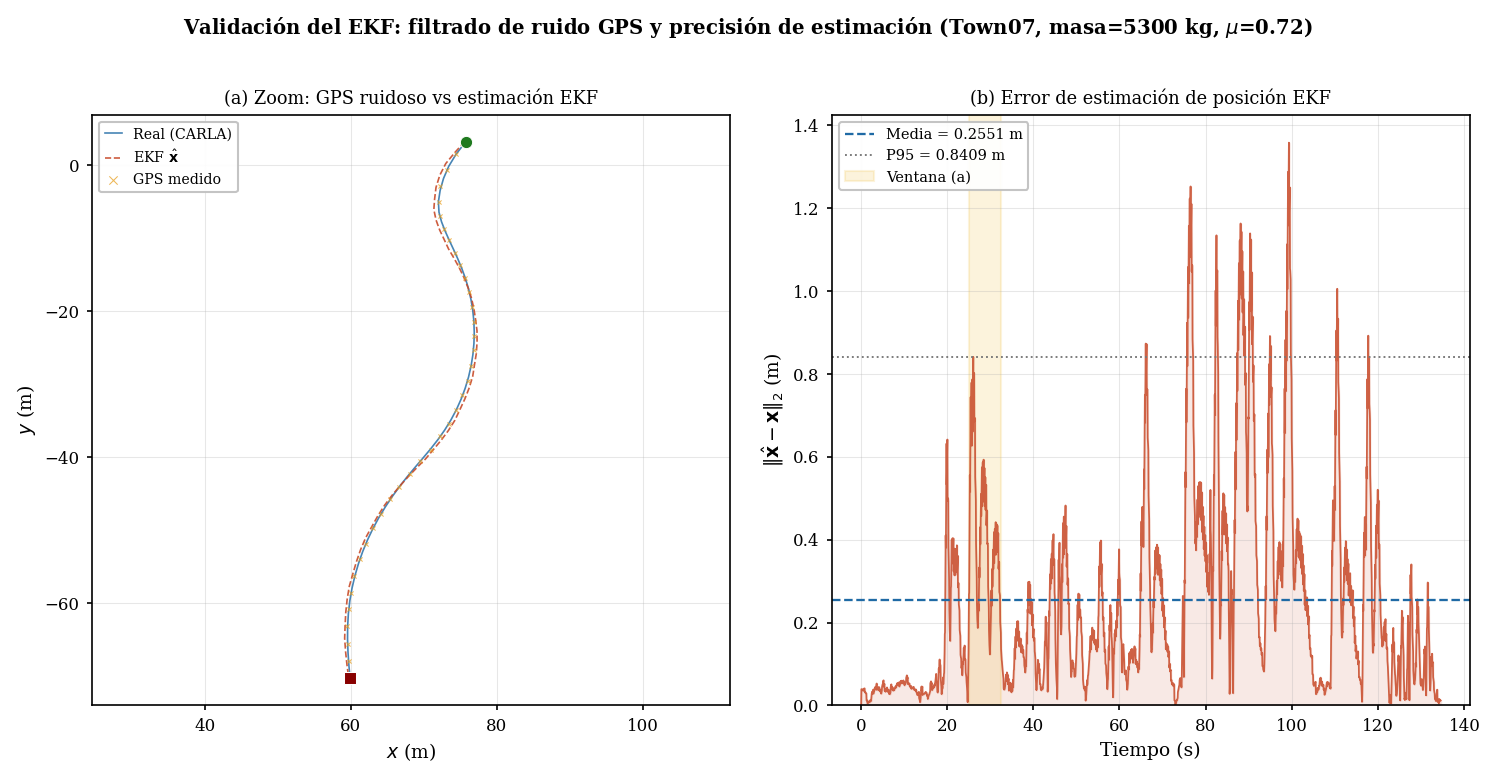

Guardado: fig_ekf_estimacion ✅


In [3]:

# ── Fig. 4.5-A  Calidad de estimación EKF ─────────────────────────────
# ┌─────────────────────────────────────────────────────────────────────┐
# │  PARÁMETROS EDITABLES                                               │
# │  AUTO = True  → busca el timestep más cercano a (X_C, Y_C)         │
# │  AUTO = False → usa I_START / I_END directamente                   │
# └─────────────────────────────────────────────────────────────────────┘
AUTO      = False
X_C       = -80.0   # coordenada x central de la sección (m)
Y_C       = -215.0  # coordenada y central de la sección (m)
WIN_STEPS = 700     # pasos a mostrar (~35 s a 20 Hz)

I_START   = 500     # solo si AUTO = False
I_END     = 650     # solo si AUTO = False
# ──────────────────────────────────────────────────────────────────────

from scipy.ndimage import uniform_filter1d

GPS_STEP = 4
DECIM    = 3

x_real = np.array(sim_ekf['x'])
y_real = np.array(sim_ekf['y'])
x_hat  = np.array(sim_ekf['x_hat'])
y_hat  = np.array(sim_ekf['y_hat'])
gps_x  = np.array(sim_ekf['gps_x'])
gps_y  = np.array(sim_ekf['gps_y'])
t_ekf  = np.array(sim_ekf['time'])

# Error de posición EKF (señal completa)
pos_err  = np.sqrt((x_hat - x_real)**2 + (y_hat - y_real)**2)
err_mean = float(np.mean(pos_err))
err_p95  = float(np.percentile(pos_err, 95))

# ── Selección de la sección ────────────────────────────────────────────
if AUTO:
    dists    = np.sqrt((x_real - X_C)**2 + (y_real - Y_C)**2)
    idx_near = int(np.argmin(dists))
    i0_z     = max(idx_near - WIN_STEPS // 2, 0)
    i1_z     = min(i0_z + WIN_STEPS, len(x_real) - 1)
else:
    i0_z, i1_z = I_START, I_END

cx = x_real[i0_z + (i1_z - i0_z) // 2]
cy = y_real[i0_z + (i1_z - i0_z) // 2]
print(f'Sección zoom : pasos [{i0_z} → {i1_z}]  '
      f't = [{t_ekf[i0_z]:.1f} → {t_ekf[i1_z]:.1f}] s')
print(f'Centro real  : x = {cx:.1f} m,  y = {cy:.1f} m')

# Segmentos zoom
xr_z = x_real[i0_z:i1_z:DECIM]
yr_z = y_real[i0_z:i1_z:DECIM]
xh_z = x_hat [i0_z:i1_z:DECIM]
yh_z = y_hat [i0_z:i1_z:DECIM]

# GPS en el rango (solo puntos de actualización real)
gps_all_idx = np.arange(GPS_STEP - 1, len(x_real), GPS_STEP)
mask_gps    = (gps_all_idx >= i0_z) & (gps_all_idx < i1_z)
gx_z = gps_x[gps_all_idx[mask_gps]]
gy_z = gps_y[gps_all_idx[mask_gps]]
print(f'GPS updates en ventana: {len(gx_z)}')

# ── Figura ────────────────────────────────────────────────────────────
fig, (ax_sp, ax_err) = plt.subplots(1, 2, figsize=(10, 5))

# ─ (a) Zoom: GPS × vs EKF vs real ───────────────────────────────────
ax_sp.plot(xr_z, yr_z,
           color='#1F6AA5', lw=0.80, alpha=0.82, zorder=3,
           label='Real (CARLA)')
ax_sp.plot(xh_z, yh_z,
           color='#C84B2A', lw=0.80, alpha=0.90, zorder=4,
           linestyle='--', label='EKF $\\hat{\\mathbf{x}}$')
ax_sp.scatter(gx_z, gy_z,
              s=4, color='#E8A020', alpha=0.75, zorder=5,
              marker='x', linewidths=0.5,
              label=f'GPS medido')

# Marcadores inicio / fin de la ventana
ax_sp.scatter(xr_z[0],  yr_z[0],  s=35, color='#1F7A1F', zorder=8,
              marker='o', edgecolors='white', linewidths=0.5)
ax_sp.scatter(xr_z[-1], yr_z[-1], s=35, color='#880000', zorder=8,
              marker='s', edgecolors='white', linewidths=0.5)

ax_sp.set_xlabel('$x$ (m)', labelpad=3)
ax_sp.set_ylabel('$y$ (m)', labelpad=3)
ax_sp.set_title('(a) Zoom: GPS ruidoso vs estimación EKF',
                fontsize=8.5, pad=5)
ax_sp.set_aspect('equal', adjustable='datalim')
ax_sp.legend(fontsize=6.8, framealpha=0.92, edgecolor='0.75',
             handlelength=1.2, loc='upper left', markerscale=2.0)
ax_sp.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax_sp.yaxis.set_major_locator(ticker.MaxNLocator(5))
ax_sp.tick_params(axis='both', length=2.5)

# ─ (b) Error temporal (señal completa + ventana resaltada) ───────────
ax_err.plot(t_ekf, pos_err, color='#C84B2A', lw=0.85, alpha=0.85)
ax_err.axhline(err_mean, color='#1F6AA5', lw=1.1, linestyle='--',
               label=f'Media = {err_mean:.4f} m')
ax_err.axhline(err_p95,  color='#777',    lw=0.9, linestyle=':',
               label=f'P95 = {err_p95:.4f} m')
ax_err.fill_between(t_ekf, pos_err, alpha=0.12, color='#C84B2A')
ax_err.axvspan(t_ekf[i0_z], t_ekf[min(i1_z, len(t_ekf)-1)],
               color='#F0C040', alpha=0.18, zorder=1,
               label='Ventana (a)')

ax_err.set_xlabel('Tiempo (s)', labelpad=3)
ax_err.set_ylabel('$\\|\\hat{\\mathbf{x}} - \\mathbf{x}\\|_2$ (m)', labelpad=3)
ax_err.set_title('(b) Error de estimación de posición EKF', fontsize=8.5, pad=5)
ax_err.set_ylim(bottom=0)
ax_err.legend(fontsize=7.0, framealpha=0.92, edgecolor='0.75')
ax_err.tick_params(axis='both', length=2.5)

fig.suptitle(
    'Validación del EKF: filtrado de ruido GPS y precisión de estimación'
    ' (Town07, masa=5300 kg, $\\mu$=0.72)',
    fontsize=9.5, fontweight='bold', y=1.02
)
plt.tight_layout(pad=0.9)
plt.savefig('fig_ekf_estimacion.pdf', bbox_inches='tight')
plt.savefig('fig_ekf_estimacion.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_ekf_estimacion ✅')


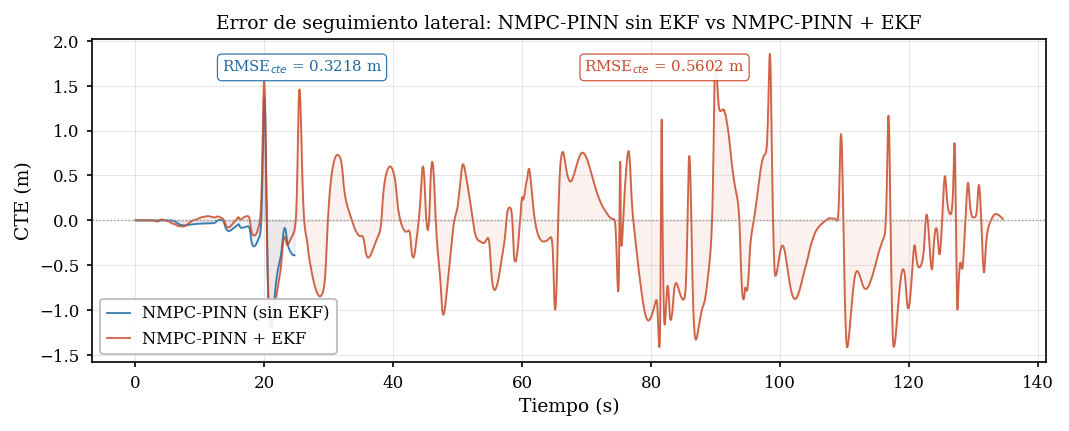

Guardado: fig_ekf_cte_comparativa ✅


In [4]:

# ── Fig. 4.5-B  CTE comparativa PINN vs PINN+EKF ─────────────────────
C_PINN = '#1F6AA5'
C_EKF  = '#C84B2A'

t_p   = np.array(sim_pinn['time'])
t_e   = np.array(sim_ekf['time'])
cte_p = np.array(sim_pinn['crosstrack_error'])
cte_e = np.array(sim_ekf['crosstrack_error'])

fig, ax = plt.subplots(figsize=(7.16, 2.9))

ax.plot(t_p, cte_p, color=C_PINN, lw=0.90, alpha=0.85,
        label='NMPC-PINN (sin EKF)')
ax.plot(t_e, cte_e, color=C_EKF,  lw=0.90, alpha=0.85,
        label='NMPC-PINN + EKF')
ax.axhline(0, color='#999', lw=0.65, linestyle=':', zorder=2)
ax.fill_between(t_p, cte_p, 0, alpha=0.07, color=C_PINN)
ax.fill_between(t_e, cte_e, 0, alpha=0.07, color=C_EKF)

# Anotaciones RMSE
for val, color, xpos in [
    (m_p['rmse'], C_PINN, 0.22),
    (m_e['rmse'], C_EKF,  0.60),
]:
    ax.text(xpos, 0.94, f'RMSE$_{{cte}}$ = {val:.4f} m',
            transform=ax.transAxes, fontsize=7.2, color=color,
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec=color, lw=0.6, alpha=0.92))

ax.set_xlabel('Tiempo (s)', labelpad=3)
ax.set_ylabel('CTE (m)', labelpad=3)
ax.set_title(
    'Error de seguimiento lateral: NMPC-PINN sin EKF vs NMPC-PINN + EKF',
    fontsize=9, pad=5
)
ax.legend(fontsize=7.8, framealpha=0.92, edgecolor='0.75',
          handlelength=1.4, loc='lower left')
ax.tick_params(axis='both', length=2.5)

plt.tight_layout(pad=0.9)
plt.savefig('fig_ekf_cte_comparativa.pdf', bbox_inches='tight')
plt.savefig('fig_ekf_cte_comparativa.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_ekf_cte_comparativa ✅')


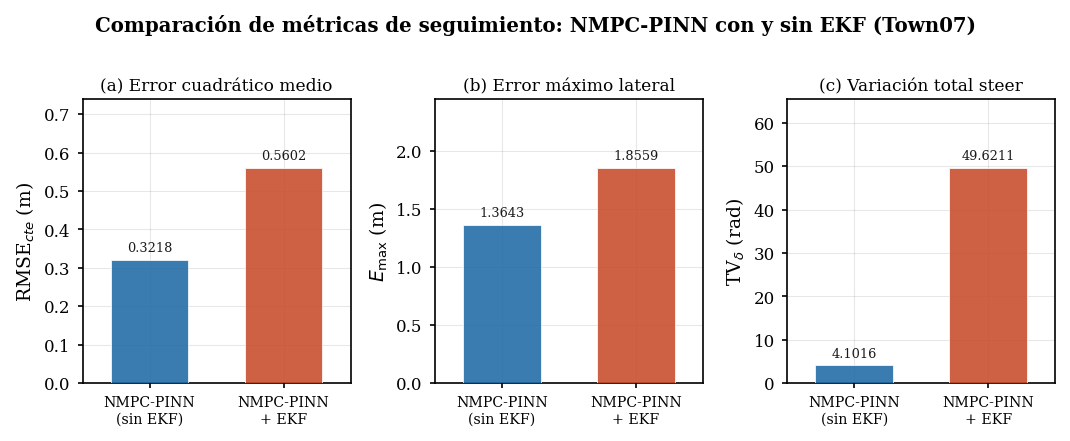

Guardado: fig_ekf_metricas ✅


In [5]:
# ── Fig. 4.5-C  M\u00e9tricas comparativas (3 paneles) ─────────────────────────
C_PINN = '#1F6AA5'
C_EKF  = '#C84B2A'

fig, axes = plt.subplots(1, 3, figsize=(7.16, 2.8))

metrics_cfg = [
    ('rmse', 'RMSE$_{cte}$ (m)',           '(a) Error cuadr\u00e1tico medio'),
    ('emax', '$E_{\\mathrm{max}}$ (m)',     '(b) Error m\u00e1ximo lateral'),
    ('tvd',  'TV$_\\delta$ (rad)',          '(c) Variaci\u00f3n total steer'),
]

xlabels = ['NMPC-PINN\n(sin EKF)', 'NMPC-PINN\n+ EKF']

for ax, (key, ylabel, title) in zip(axes, metrics_cfg):
    vals   = [m_p[key], m_e[key]]
    colors = [C_PINN,   C_EKF]
    ymax   = max(vals) * 1.32

    for j, (v, c) in enumerate(zip(vals, colors)):
        ax.bar(j, v, 0.58, color=c, alpha=0.88,
               edgecolor='white', linewidth=0.4, zorder=3)
        ax.text(j, v + ymax * 0.018, f'{v:.4f}',
                ha='center', va='bottom', fontsize=6.2, color='#1a1a1a')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(xlabels, fontsize=6.8)
    ax.set_ylabel(ylabel, labelpad=3)
    ax.set_title(title, fontsize=8.2, pad=4)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0, ymax)
    ax.tick_params(axis='both', length=2.5)

fig.suptitle(
    'Comparaci\u00f3n de m\u00e9tricas de seguimiento: NMPC-PINN con y sin EKF (Town07)',
    fontsize=9.5, fontweight='bold', y=1.02
)
plt.tight_layout(pad=0.9)
plt.savefig('fig_ekf_metricas.pdf', bbox_inches='tight')
plt.savefig('fig_ekf_metricas.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_ekf_metricas \u2705')

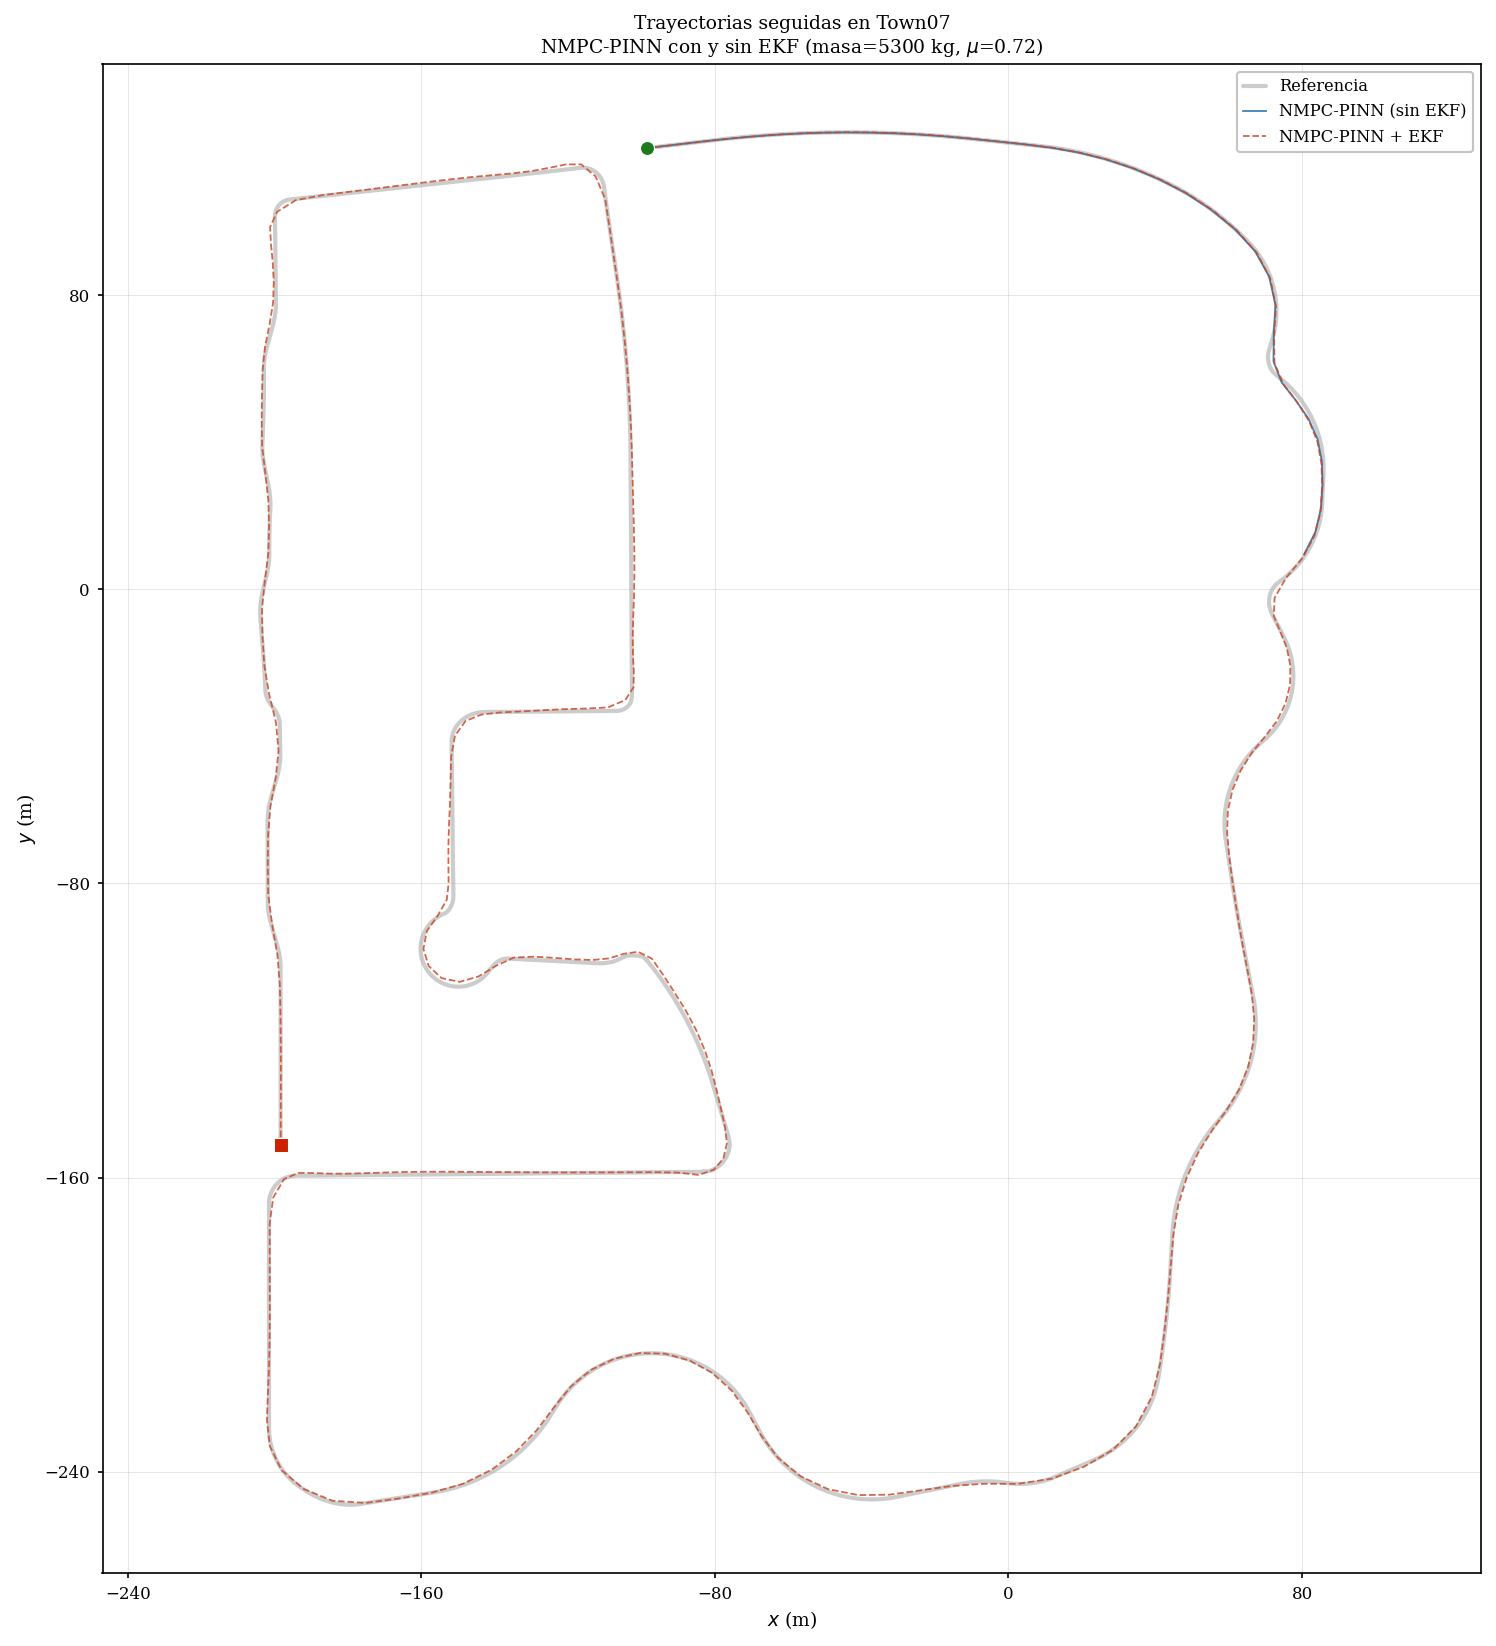

Guardado: fig_ekf_trayectorias ✅


In [6]:
# ── Fig. 4.5-D  Trayectorias comparativas en Town07 ───────────────────
DECIM_T = 10
C_PINN  = '#1F6AA5'
C_EKF   = '#C84B2A'

x_ref = traj['x'][::DECIM_T]
y_ref = traj['y'][::DECIM_T]
x_p   = np.array(sim_pinn['x'])[::DECIM_T]
y_p   = np.array(sim_pinn['y'])[::DECIM_T]
x_e   = np.array(sim_ekf['x'])[::DECIM_T]
y_e   = np.array(sim_ekf['y'])[::DECIM_T]

fig, ax = plt.subplots(figsize=(10, 11))

ax.plot(x_ref, y_ref,
        color='#CCCCCC', lw=2.0, zorder=1,
        solid_capstyle='round', label='Referencia')
ax.plot(x_p, y_p,
        color=C_PINN, lw=0.85, alpha=0.85, zorder=3,
        label='NMPC-PINN (sin EKF)')
ax.plot(x_e, y_e,
        color=C_EKF, lw=0.85, alpha=0.85, zorder=4,
        linestyle='--', label='NMPC-PINN + EKF')

# Marcadores inicio / fin
ax.scatter(x_ref[0],  y_ref[0],  s=45, color='#1F7A1F', zorder=8,
           marker='o', edgecolors='white', linewidths=0.5)
ax.scatter(x_ref[-1], y_ref[-1], s=45, color='#CC2200', zorder=8,
           marker='s', edgecolors='white', linewidths=0.5)

ax.set_xlabel('$x$ (m)', labelpad=3)
ax.set_ylabel('$y$ (m)', labelpad=3)
ax.set_title(
    'Trayectorias seguidas en Town07\n'
    'NMPC-PINN con y sin EKF (masa=5300 kg, $\\mu$=0.72)',
    fontsize=9, pad=5
)
ax.set_aspect('equal', adjustable='datalim')
ax.legend(fontsize=7.8, framealpha=0.92, edgecolor='0.75',
          handlelength=1.4, loc='best')
ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
ax.tick_params(axis='both', length=2.5)

plt.tight_layout(pad=0.9)
plt.savefig('fig_ekf_trayectorias.pdf', bbox_inches='tight')
plt.savefig('fig_ekf_trayectorias.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_ekf_trayectorias \u2705')

<tmp>\ipykernel.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.85)


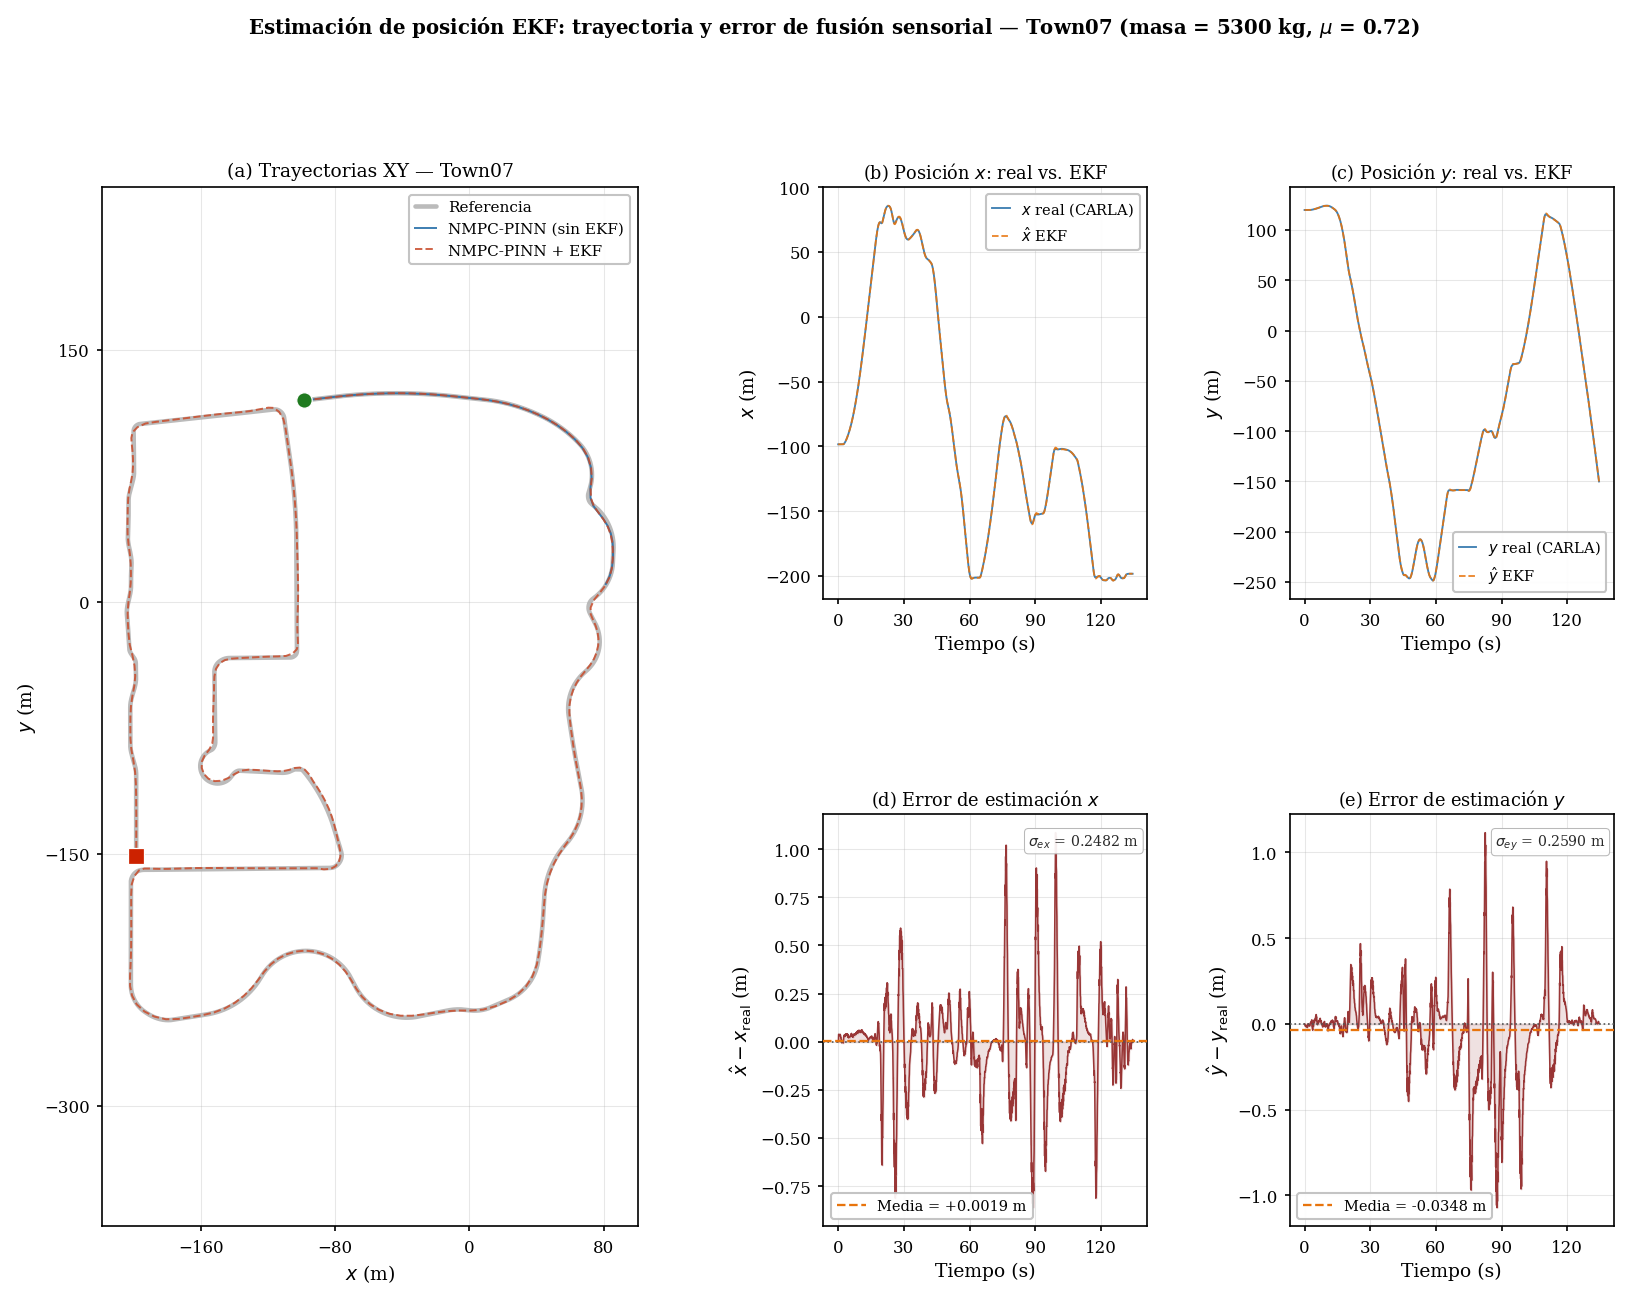

Guardado: fig_ekf_posicion_estimada ✅
Error X — media: +0.00186 m  |  σ: 0.24816 m
Error Y — media: -0.03477 m  |  σ: 0.25903 m


In [7]:
# ── Fig. 4.5-E  Trayectoria XY + estimación de posición EKF ──────────
# Layout: izquierda XY (100% height) | derecha 2×2
#         (b) X real vs X_hat   (c) Y real vs Y_hat
#         (d) Error X = x̂ − x   (e) Error Y = ŷ − y
import matplotlib.gridspec as gridspec

C_PINN  = '#1F6AA5'   # azul — PINN sin EKF
C_EKF   = '#C84B2A'   # rojo — PINN + EKF (trayectoria)
C_REF   = '#BBBBBB'   # gris claro — referencia
C_EKFH  = '#E8740C'   # naranja — estimación EKF (x_hat, y_hat)
C_ERR   = '#8B1A1A'   # rojo oscuro — error de estimación

DECIM_T = 8

# ── Arrays ──────────────────────────────────────────────────────────
x_ref_f = traj['x']
y_ref_f = traj['y']
x_p_f   = np.array(sim_pinn['x'])
y_p_f   = np.array(sim_pinn['y'])
x_e_f   = np.array(sim_ekf['x'])
y_e_f   = np.array(sim_ekf['y'])
x_hat_f = np.array(sim_ekf['x_hat'])
y_hat_f = np.array(sim_ekf['y_hat'])
t_e_f   = np.array(sim_ekf['time'])

err_x = x_hat_f - x_e_f
err_y = y_hat_f - y_e_f

# Decimados para XY
x_ref_d = x_ref_f[::DECIM_T];  y_ref_d = y_ref_f[::DECIM_T]
x_p_d   = x_p_f[::DECIM_T];    y_p_d   = y_p_f[::DECIM_T]
x_e_d   = x_e_f[::DECIM_T];    y_e_d   = y_e_f[::DECIM_T]

# ── Layout ──────────────────────────────────────────────────────────
fig      = plt.figure(figsize=(13, 9))
gs_main  = gridspec.GridSpec(1, 2, figure=fig,
                              width_ratios=[1.05, 1.55], wspace=0.28)
ax_xy    = fig.add_subplot(gs_main[0])
gs_right = gs_main[1].subgridspec(2, 2, hspace=0.52, wspace=0.44)
ax_xr    = fig.add_subplot(gs_right[0, 0])
ax_yr    = fig.add_subplot(gs_right[0, 1])
ax_ex    = fig.add_subplot(gs_right[1, 0])
ax_ey    = fig.add_subplot(gs_right[1, 1])

# ─ (a) Trayectorias XY ─────────────────────────────────────────────
ax_xy.plot(x_ref_d, y_ref_d, color=C_REF, lw=2.2, zorder=1,
           solid_capstyle='round', label='Referencia')
ax_xy.plot(x_p_d, y_p_d, color=C_PINN, lw=0.95, alpha=0.85,
           zorder=3, label='NMPC-PINN (sin EKF)')
ax_xy.plot(x_e_d, y_e_d, color=C_EKF,  lw=0.95, alpha=0.85,
           zorder=4, linestyle='--', label='NMPC-PINN + EKF')
ax_xy.scatter(x_ref_d[0],  y_ref_d[0],  s=55, color='#1F7A1F',
              zorder=8, marker='o', edgecolors='white', linewidths=0.6)
ax_xy.scatter(x_ref_d[-1], y_ref_d[-1], s=55, color='#CC2200',
              zorder=8, marker='s', edgecolors='white', linewidths=0.6)
ax_xy.set_xlabel('$x$ (m)', labelpad=3)
ax_xy.set_ylabel('$y$ (m)', labelpad=3)
ax_xy.set_title('(a) Trayectorias XY — Town07', fontsize=9, pad=5)
ax_xy.set_aspect('equal', adjustable='datalim')
ax_xy.legend(fontsize=7.3, framealpha=0.92, edgecolor='0.75',
             handlelength=1.4, loc='best')
ax_xy.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax_xy.yaxis.set_major_locator(ticker.MaxNLocator(6))
ax_xy.tick_params(axis='both', length=2.5)

# ─ (b) X real vs X̂ EKF ─────────────────────────────────────────────
ax_xr.plot(t_e_f, x_e_f,   color=C_PINN, lw=0.90, alpha=0.85,
           label='$x$ real (CARLA)')
ax_xr.plot(t_e_f, x_hat_f, color=C_EKFH, lw=0.85, ls='--', alpha=0.90,
           label='$\\hat{x}$ EKF')
ax_xr.set_xlabel('Tiempo (s)', labelpad=3)
ax_xr.set_ylabel('$x$ (m)', labelpad=3)
ax_xr.set_title('(b) Posición $x$: real vs. EKF', fontsize=8.5, pad=4)
ax_xr.legend(fontsize=7.0, framealpha=0.92, edgecolor='0.75',
             handlelength=1.2)
ax_xr.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax_xr.tick_params(axis='both', length=2.5)

# ─ (c) Y real vs Ŷ EKF ─────────────────────────────────────────────
ax_yr.plot(t_e_f, y_e_f,   color=C_PINN, lw=0.90, alpha=0.85,
           label='$y$ real (CARLA)')
ax_yr.plot(t_e_f, y_hat_f, color=C_EKFH, lw=0.85, ls='--', alpha=0.90,
           label='$\\hat{y}$ EKF')
ax_yr.set_xlabel('Tiempo (s)', labelpad=3)
ax_yr.set_ylabel('$y$ (m)', labelpad=3)
ax_yr.set_title('(c) Posición $y$: real vs. EKF', fontsize=8.5, pad=4)
ax_yr.legend(fontsize=7.0, framealpha=0.92, edgecolor='0.75',
             handlelength=1.2)
ax_yr.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax_yr.tick_params(axis='both', length=2.5)

# ─ (d) Error X = x̂ − x_real ────────────────────────────────────────
ex_mean = float(np.mean(err_x))
ex_std  = float(np.std(err_x))
ax_ex.plot(t_e_f, err_x, color=C_ERR, lw=0.75, alpha=0.85, zorder=3)
ax_ex.fill_between(t_e_f, err_x, alpha=0.13, color=C_ERR)
ax_ex.axhline(0,       color='#555555', lw=0.8, ls=':', zorder=4)
ax_ex.axhline(ex_mean, color=C_EKFH,   lw=1.1, ls='--', zorder=5,
              label=f'Media = {ex_mean:+.4f} m')
ax_ex.set_xlabel('Tiempo (s)', labelpad=3)
ax_ex.set_ylabel('$\\hat{x} - x_{\\mathrm{real}}$ (m)', labelpad=3)
ax_ex.set_title('(d) Error de estimación $x$', fontsize=8.5, pad=4)
ax_ex.legend(fontsize=7.0, framealpha=0.92, edgecolor='0.75',
             loc='lower left')
ax_ex.text(0.975, 0.955,
           f'$\\sigma_{{ex}}$ = {ex_std:.4f} m',
           transform=ax_ex.transAxes, fontsize=6.8,
           ha='right', va='top', color='#2a2a2a',
           bbox=dict(boxstyle='round,pad=0.28', fc='white',
                     ec='0.70', lw=0.5, alpha=0.92))
ax_ex.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax_ex.tick_params(axis='both', length=2.5)

# ─ (e) Error Y = ŷ − y_real ────────────────────────────────────────
ey_mean = float(np.mean(err_y))
ey_std  = float(np.std(err_y))
ax_ey.plot(t_e_f, err_y, color=C_ERR, lw=0.75, alpha=0.85, zorder=3)
ax_ey.fill_between(t_e_f, err_y, alpha=0.13, color=C_ERR)
ax_ey.axhline(0,       color='#555555', lw=0.8, ls=':', zorder=4)
ax_ey.axhline(ey_mean, color=C_EKFH,   lw=1.1, ls='--', zorder=5,
              label=f'Media = {ey_mean:+.4f} m')
ax_ey.set_xlabel('Tiempo (s)', labelpad=3)
ax_ey.set_ylabel('$\\hat{y} - y_{\\mathrm{real}}$ (m)', labelpad=3)
ax_ey.set_title('(e) Error de estimación $y$', fontsize=8.5, pad=4)
ax_ey.legend(fontsize=7.0, framealpha=0.92, edgecolor='0.75',
             loc='lower left')
ax_ey.text(0.975, 0.955,
           f'$\\sigma_{{ey}}$ = {ey_std:.4f} m',
           transform=ax_ey.transAxes, fontsize=6.8,
           ha='right', va='top', color='#2a2a2a',
           bbox=dict(boxstyle='round,pad=0.28', fc='white',
                     ec='0.70', lw=0.5, alpha=0.92))
ax_ey.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax_ey.tick_params(axis='both', length=2.5)

# ── Título global + guardar ──────────────────────────────────────────
fig.suptitle(
    'Estimación de posición EKF: trayectoria y error de fusión sensorial'
    ' — Town07 (masa = 5300 kg, $\\mu$ = 0.72)',
    fontsize=9.5, fontweight='bold', y=1.008
)
plt.tight_layout(pad=0.85)
plt.savefig('fig_ekf_posicion_estimada.pdf', bbox_inches='tight')
plt.savefig('fig_ekf_posicion_estimada.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_ekf_posicion_estimada ✅')
print(f'Error X — media: {ex_mean:+.5f} m  |  σ: {ex_std:.5f} m')
print(f'Error Y — media: {ey_mean:+.5f} m  |  σ: {ey_std:.5f} m')